# House Prices: Advanced Regression Techniques
### End-to-end notebook — EDA → Cleaning → Feature Engineering → Modeling → Submission

This notebook works through the full Kaggle competition **[House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)** from raw data to a submission file.

**Task**: predict `SalePrice` for houses in Ames, Iowa from 79 explanatory variables (structural, quality, location, and time features). Evaluation metric is **RMSE between the log of the predicted price and the log of the actual price** — meaning we should model `log(SalePrice)`, not raw price.

**Before running this notebook**, download `train.csv`, `test.csv`, `data_description.txt`, and `sample_submission.csv` from the [Kaggle competition data page](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) (you must accept the competition rules and be logged in — Kaggle downloads can't be automated from here) and place them in the **same folder as this notebook**.

**Notebook structure**
1. Setup & data loading
2. Exploratory Data Analysis (EDA)
3. Data cleaning (missing values)
4. Feature engineering
5. Preprocessing pipeline (encoding, scaling, transforms)
6. Baseline & regularized linear models
7. Tree-based models
8. Hyperparameter tuning
9. Ensembling & stacking
10. Final model, prediction, and submission file
11. Conclusion & next steps

**A note on approach**: this notebook intentionally sticks to plain scikit-learn estimators (linear models, Random Forest, Gradient Boosting) rather than external boosting libraries like XGBoost/LightGBM, and writes cross-validation, hyperparameter search, and stacking as explicit, readable loops instead of calling `RandomizedSearchCV` or `StackingRegressor`. Nothing here is a black box — every score you see comes from code you can read line-by-line.


## 1. Setup & Imports

In [1]:
# Core
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, norm

# Modeling — deliberately sticking to plain scikit-learn estimators
# (no xgboost/lightgbm) and writing cross-validation, tuning, and
# stacking as explicit loops rather than calling black-box helpers,
# so every step is visible and easy to follow/modify.
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load the raw files (must be in the same directory as this notebook)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Keep Id columns aside for the final submission, then drop from working frames
train_ID = train['Id']
test_ID = test['Id']

train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)


## 2. Exploratory Data Analysis (EDA)

Goal: understand the target variable, spot data quality issues (missing values, outliers), and see which features look predictive before we commit to a cleaning/engineering plan.

### 2.1 Target variable — `SalePrice`

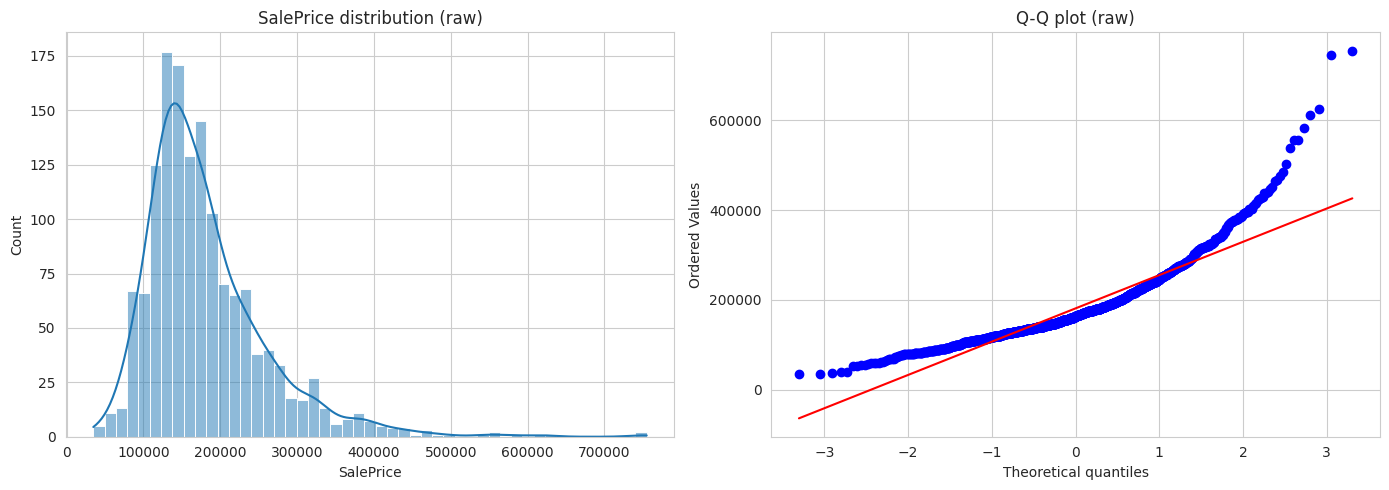

Skewness: 1.883
Kurtosis: 6.536


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice distribution (raw)')

stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q plot (raw)')

plt.tight_layout()
plt.show()

print('Skewness: %.3f' % train['SalePrice'].skew())
print('Kurtosis: %.3f' % train['SalePrice'].kurt())


`SalePrice` is right-skewed with a long tail of expensive houses. Linear models assume roughly normal, homoscedastic errors, and the competition's own metric evaluates errors on the **log** scale — so we log-transform the target with `log1p` (log(1+x), which is safe and its inverse `expm1` recovers the original scale cleanly).

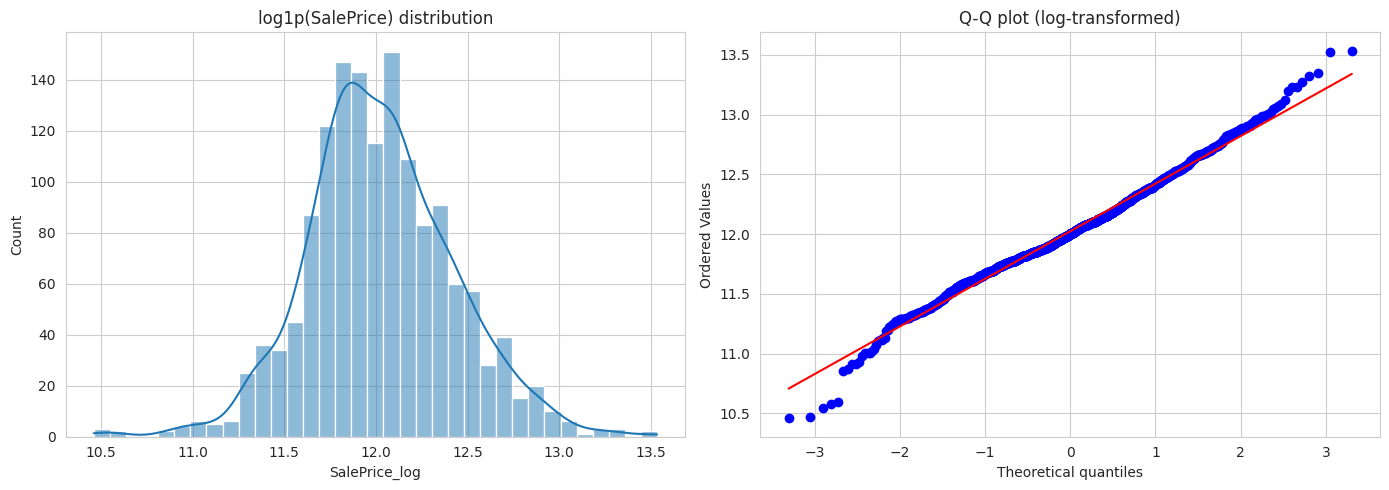

Skewness after log1p: 0.121


In [5]:
train['SalePrice_log'] = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['SalePrice_log'], kde=True, ax=axes[0])
axes[0].set_title('log1p(SalePrice) distribution')
stats.probplot(train['SalePrice_log'], plot=axes[1])
axes[1].set_title('Q-Q plot (log-transformed)')
plt.tight_layout()
plt.show()

print('Skewness after log1p: %.3f' % train['SalePrice_log'].skew())


Much closer to normal — this is the target we'll actually train on.

### 2.2 Missing data

In [6]:
def missing_table(df):
    total = df.isnull().sum()
    pct = 100 * total / len(df)
    tbl = pd.concat([total, pct], axis=1, keys=['Total', 'Percent'])
    return tbl[tbl['Total'] > 0].sort_values('Percent', ascending=False)

miss_train = missing_table(train.drop(columns=['SalePrice', 'SalePrice_log']))
miss_train


,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


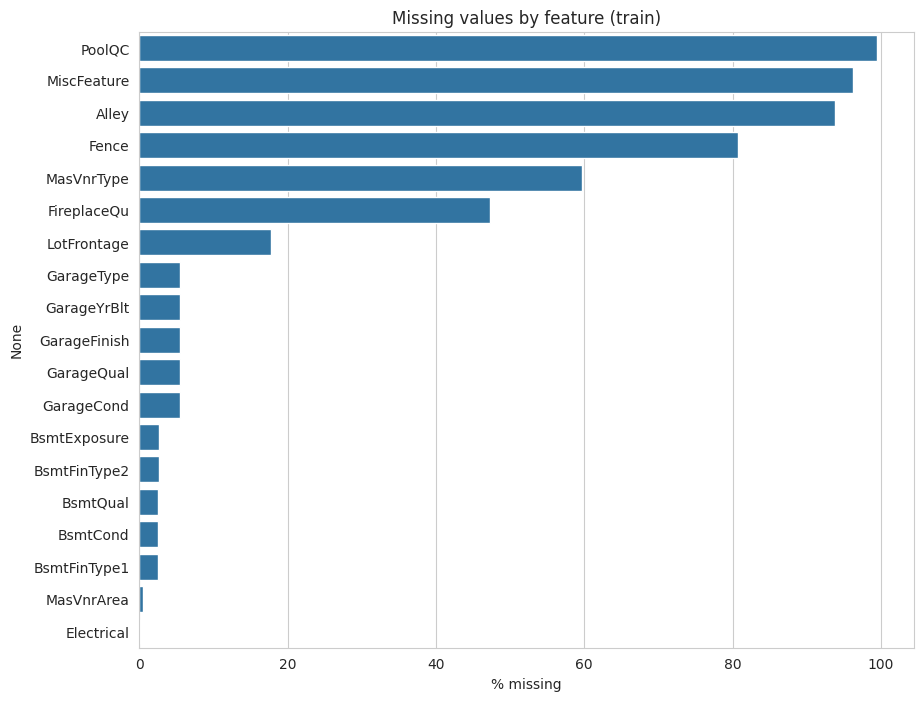

In [7]:
plt.figure(figsize=(10, 8))
sns.barplot(x=miss_train['Percent'], y=miss_train.index)
plt.title('Missing values by feature (train)')
plt.xlabel('% missing')
plt.show()


Most of these are **not** data-quality problems — checking `data_description.txt` shows that for features like `PoolQC`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`, `BsmtQual`, etc., `NaN` literally means *"the house doesn't have this feature"* (no pool, no alley access, no fence...). We'll encode those as an explicit `"None"` category rather than imputing a typical value. A few (`LotFrontage`, `GarageYrBlt`) are genuinely missing values to impute. We'll handle the details in Section 3.

### 2.3 Numerical feature distributions & relationship to price

In [8]:
num_features = train.select_dtypes(include=[np.number]).columns.drop(['SalePrice', 'SalePrice_log'])
print(f'{len(num_features)} numerical features')

corr = train[list(num_features) + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
corr.drop('SalePrice').head(15)


36 numerical features


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

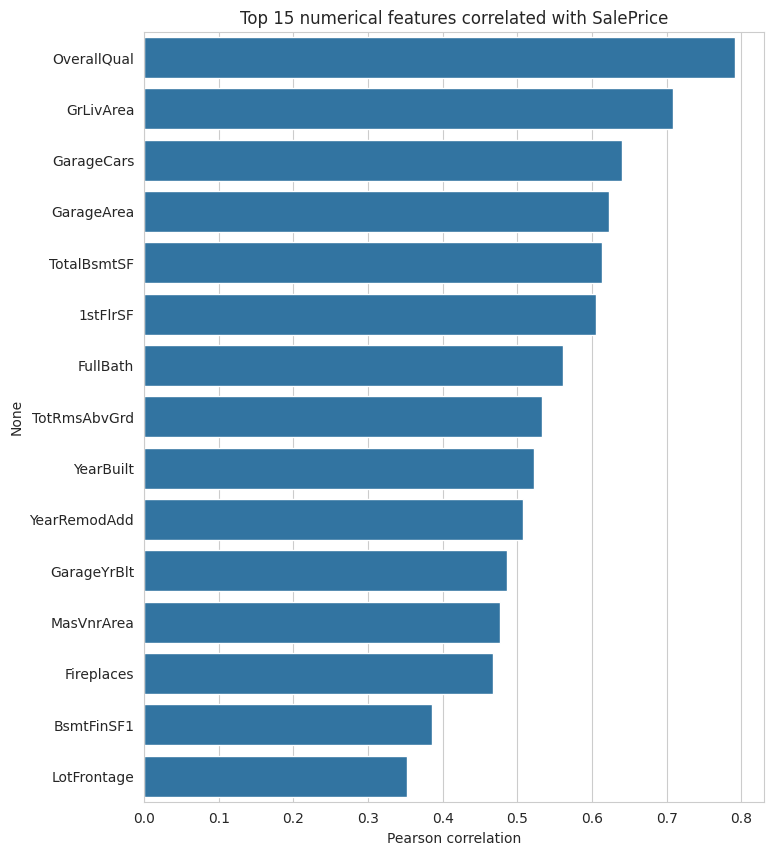

In [9]:
plt.figure(figsize=(8, 10))
top_corr = corr.drop('SalePrice').head(15)
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top 15 numerical features correlated with SalePrice')
plt.xlabel('Pearson correlation')
plt.show()


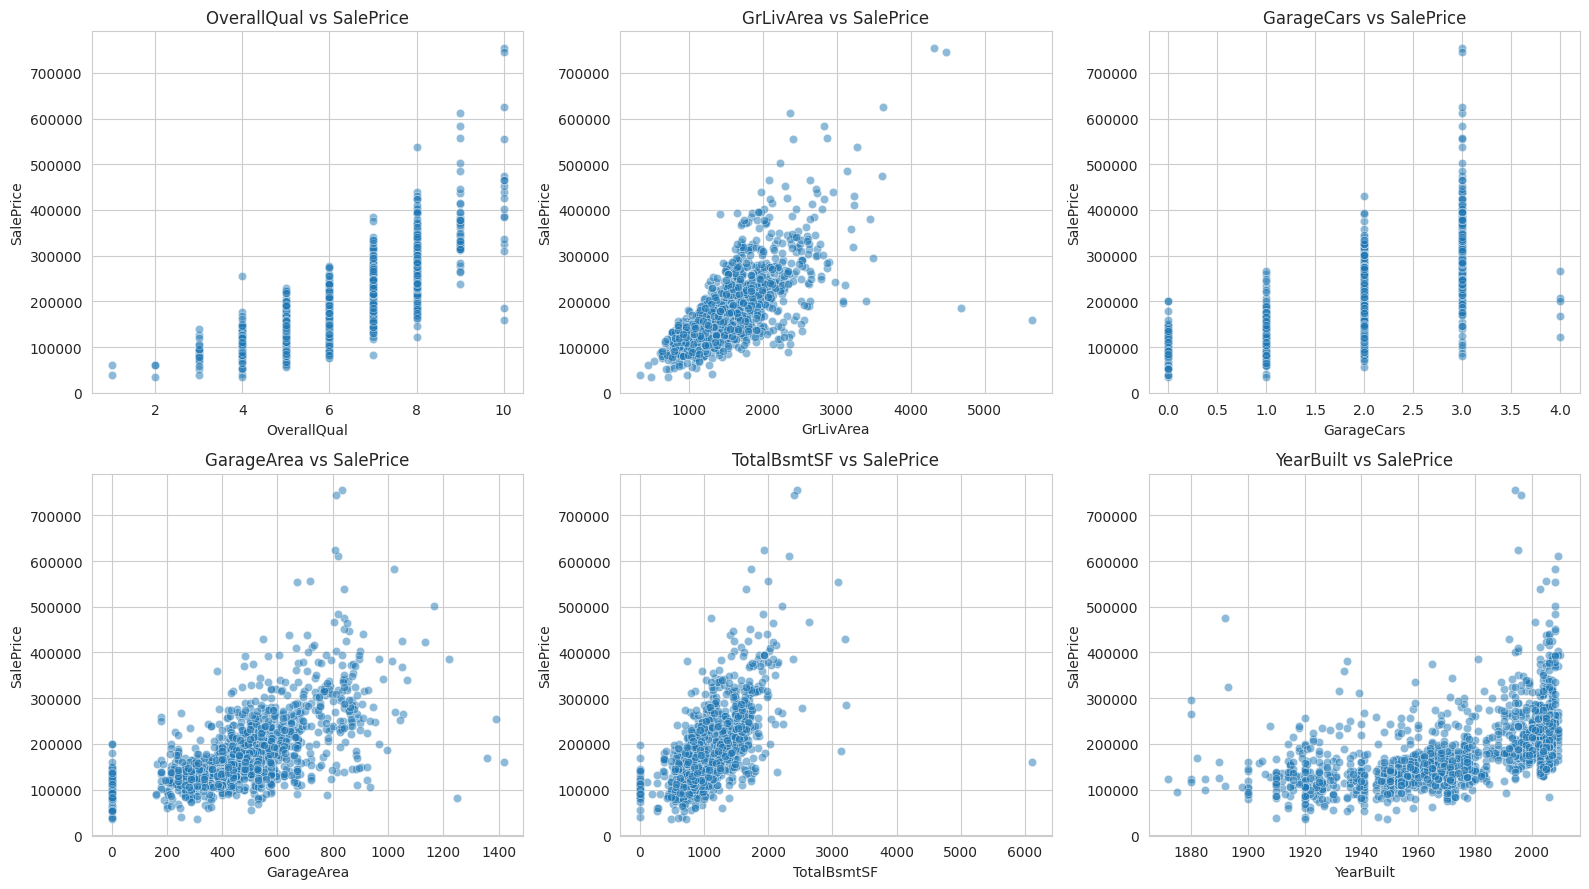

In [10]:
top_feats = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, top_feats):
    sns.scatterplot(x=train[feat], y=train['SalePrice'], ax=ax, alpha=0.5)
    ax.set_title(f'{feat} vs SalePrice')
plt.tight_layout()
plt.show()


`OverallQual` (an ordinal 1-10 quality rating) and `GrLivArea` (above-ground living area) are the strongest single predictors — unsurprising for real estate. Note the two houses in the bottom-right of the `GrLivArea` plot: >4000 sq ft but *low* price. These are well-known outliers in this dataset and are commonly removed (we do this in Section 4).

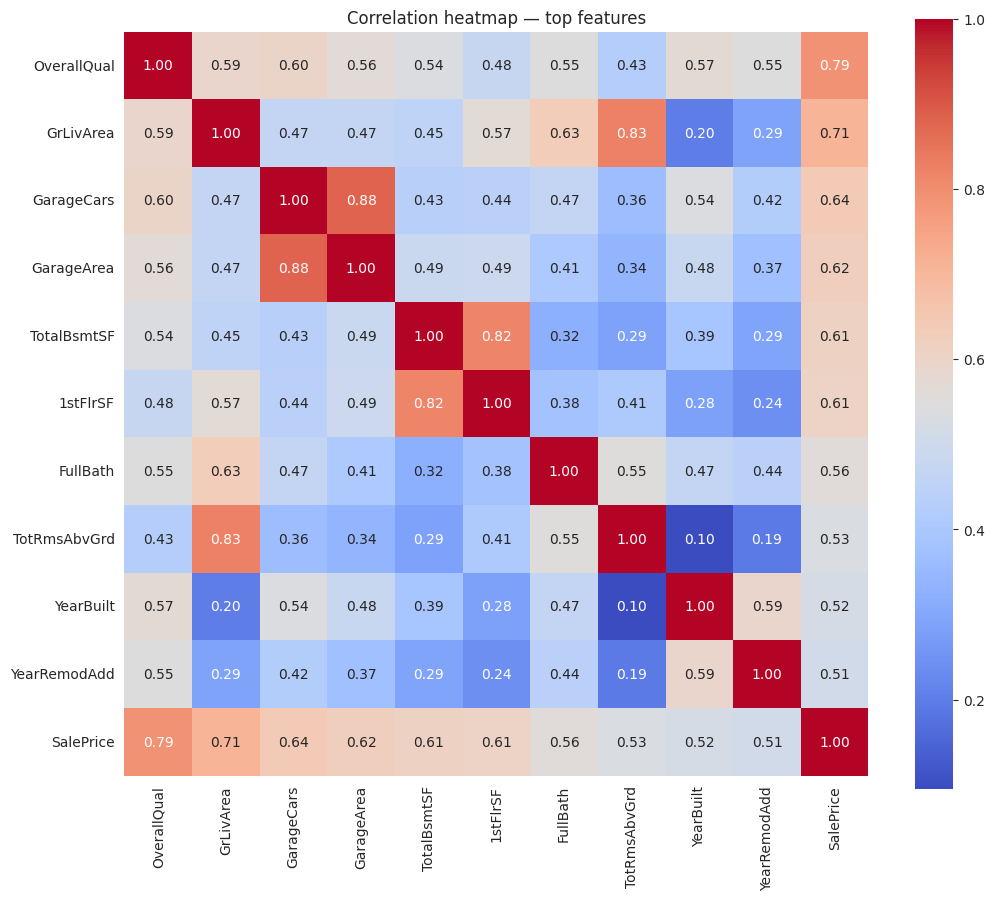

In [11]:
plt.figure(figsize=(12, 10))
top_corr_matrix = train[corr.drop('SalePrice').head(10).index.tolist() + ['SalePrice']].corr()
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation heatmap — top features')
plt.show()


Note some multicollinearity: `GarageCars`/`GarageArea` and `TotalBsmtSF`/`1stFlrSF` are pairs that carry overlapping information. Regularized linear models (Ridge/Lasso) handle this better than plain OLS, and tree models are unaffected.

### 2.4 Categorical features

43 categorical features


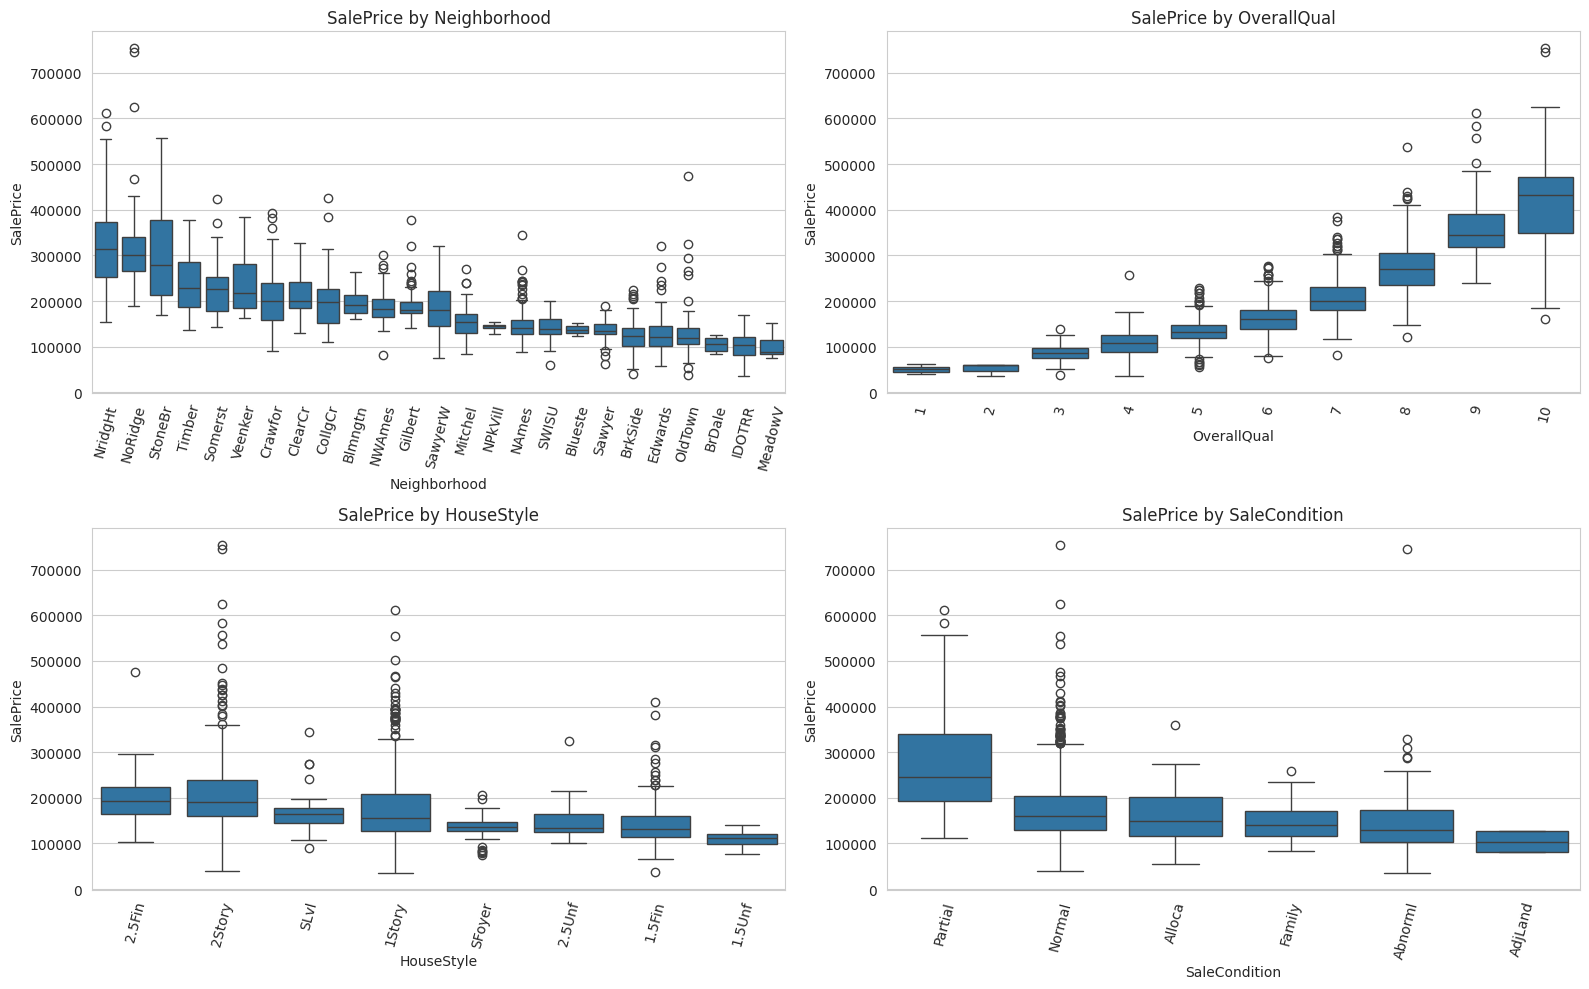

In [12]:
cat_features = train.select_dtypes(exclude=[np.number]).columns
print(f'{len(cat_features)} categorical features')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.flat, ['Neighborhood', 'OverallQual', 'HouseStyle', 'SaleCondition']):
    if feat == 'OverallQual':
        order = sorted(train[feat].unique())
    else:
        order = train.groupby(feat)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=feat, y='SalePrice', data=train, order=order, ax=ax)
    ax.set_title(f'SalePrice by {feat}')
    ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


`Neighborhood` shows a large spread in median price — location matters a lot, and it's a high-cardinality categorical we'll one-hot encode. `OverallQual` cleanly separates price bands, confirming it as a strong ordinal predictor.

## 3. Data Cleaning

We combine train and test into a single frame so every imputation/encoding rule is applied identically to both (critical — the model will fail if train/test columns don't match after encoding).

In [13]:
# Remove outliers identified in EDA (huge living area, abnormally low price) — only from TRAIN
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)
train.reset_index(drop=True, inplace=True)
print('Train shape after outlier removal:', train.shape)


Train shape after outlier removal: (1458, 81)


In [14]:
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train['SalePrice_log'].values

all_data = pd.concat([train.drop(['SalePrice', 'SalePrice_log'], axis=1), test]).reset_index(drop=True)
print('Combined shape:', all_data.shape)


Combined shape: (2917, 79)


### 3.1 Missing values — "None" means no such feature

For these columns, `NaN` = the house doesn't have this feature at all (per `data_description.txt`).

In [15]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')


### 3.2 Missing values — numeric zeros

In [16]:
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)


### 3.3 Missing values — impute from context

In [17]:
# LotFrontage: similar houses in the same neighborhood tend to have similar frontage
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# MSZoning: fill with the most common zoning within the same MSSubClass
all_data['MSZoning'] = all_data.groupby('MSSubClass')['MSZoning'].transform(
    lambda x: x.fillna(x.mode()[0])
)

# Functional: data description says NA means "typical"
all_data['Functional'] = all_data['Functional'].fillna('Typ')

# A handful of columns with only 1-2 missing values: fill with the mode
mode_cols = ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Utilities: almost all rows are 'AllPub' -> not informative, drop it
all_data = all_data.drop(['Utilities'], axis=1)


In [18]:
remaining_missing = all_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print('Columns still missing values:', list(remaining_missing.index))
assert remaining_missing.empty, 'There are still missing values!'


Columns still missing values: []


## 4. Feature Engineering

### 4.1 New composite features
Combine related raw columns into features that map more directly onto "what a buyer cares about" — total living space, house age, total bathrooms, etc.

In [19]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

all_data['TotalBathrooms'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                               all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt']
all_data.loc[all_data['GarageYrBlt'] == 0, 'GarageAge'] = 0  # no garage

all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print('New feature count check — shape:', all_data.shape)


New feature count check — shape: (2917, 89)


### 4.2 Ordinal encoding for quality/condition features
Columns like `ExterQual`, `KitchenQual`, `BsmtQual` are ordered categories (`Ex > Gd > TA > Fa > Po > None`). Mapping them to integers preserves that order — one-hot encoding would throw it away.

In [20]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map)

bsmt_exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(bsmt_exposure_map)

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map)

garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
all_data['GarageFinish'] = all_data['GarageFinish'].map(garage_finish_map)

functional_map = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4,
                   'Min2': 5, 'Min1': 6, 'Typ': 7}
all_data['Functional'] = all_data['Functional'].map(functional_map)


### 4.3 `MSSubClass`, `MoSold` are categorical, not numeric
They're stored as integers but represent categories (a building-class code, a calendar month) — treating them as ordinal numbers would imply a false ordering.

In [21]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)


### 4.4 Fix skewed numeric features
Many remaining numeric features (areas, counts) are also right-skewed. We apply a Box-Cox transform (generalized log) to features with |skew| > 0.75, which tends to help linear models more than tree models but doesn't hurt either.

In [22]:
from scipy.special import boxcox1p

numeric_feats = all_data.select_dtypes(include=[np.number]).columns
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = skewed_feats[abs(skewed_feats) > 0.75]
print(f'{len(skewness)} skewed numeric features to transform')
skewness.head(10)


34 skewed numeric features to transform


MiscVal          21.939672
PoolQC           19.548879
PoolArea         17.688664
HasPool          15.494756
LotArea          13.109495
LowQualFinSF     12.084539
3SsnPorch        11.372080
KitchenAbvGr      4.300550
BsmtFinSF2        4.144503
EnclosedPorch     4.002344
dtype: float64

In [23]:
lam = 0.15
for feat in skewness.index:
    all_data[feat] = boxcox1p(all_data[feat], lam)


### 4.5 One-hot encode remaining (nominal) categorical features

In [24]:
all_data = pd.get_dummies(all_data, drop_first=True)
print('Final feature matrix shape:', all_data.shape)


Final feature matrix shape: (2917, 242)


### 4.6 Split back into train/test

In [25]:
X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test :', X_test.shape)


X_train: (1458, 242)  y_train: (1458,)
X_test : (1459, 242)


## 5. Modeling

### 5.1 Evaluation setup

The competition metric is RMSE on `log(SalePrice)` — since we already trained on `SalePrice_log`, plain RMSE on our target *is* the competition metric.

Rather than calling `cross_val_score` as a black box, we write the K-fold loop out by hand: split the training data into 5 folds, and for each fold, clone a fresh (untrained) copy of the model, fit it on the other 4 folds, predict on the held-out fold, and record that fold's RMSE. This makes it obvious exactly what's being measured and makes it easy to inspect per-fold behavior later if something looks off.

In [26]:
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

def rmse_cv(estimator, X=X_train, y=y_train, folds=kf):
    """Manual K-fold cross-validation: returns one RMSE per fold."""
    scores = []
    for train_idx, val_idx in folds.split(X):
        model = clone(estimator)                 # fresh, untrained copy
        model.fit(X.iloc[train_idx], y[train_idx])
        preds = model.predict(X.iloc[val_idx])
        fold_rmse = np.sqrt(np.mean((preds - y[val_idx]) ** 2))
        scores.append(fold_rmse)
    return np.array(scores)

results = {}


### 5.2 Baseline: Linear Regression
A plain OLS baseline. With ~200+ engineered/dummy features, we expect this to overfit somewhat — useful as a lower bar for the regularized models.

In [27]:
lr = LinearRegression()
score = rmse_cv(lr)
results['LinearRegression'] = score
print(f'Linear Regression RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


Linear Regression RMSE: 0.1664 (+/- 0.0590)


### 5.3 Regularized linear models: Ridge, Lasso, ElasticNet

In [28]:
ridge_pipe = make_pipeline(RobustScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50)))
score = rmse_cv(ridge_pipe)
results['Ridge'] = score
print(f'Ridge RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


Ridge RMSE: 0.1142 (+/- 0.0086)


In [29]:
lasso_pipe = make_pipeline(RobustScaler(), LassoCV(alphas=np.logspace(-4, 1, 50), max_iter=50000, random_state=RANDOM_STATE))
score = rmse_cv(lasso_pipe)
results['Lasso'] = score
print(f'Lasso RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


Lasso RMSE: 0.1141 (+/- 0.0076)


In [30]:
enet_pipe = make_pipeline(RobustScaler(), ElasticNetCV(alphas=np.logspace(-4, 1, 30),
                                                          l1_ratio=[.1, .3, .5, .7, .9, .95, 1],
                                                          max_iter=50000, random_state=RANDOM_STATE))
score = rmse_cv(enet_pipe)
results['ElasticNet'] = score
print(f'ElasticNet RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


ElasticNet RMSE: 0.1139 (+/- 0.0076)


`RobustScaler` (median/IQR-based) is used instead of `StandardScaler` because it's less sensitive to the outliers we may have missed. `LassoCV`/`ElasticNetCV`/`RidgeCV` each search their own regularization strength internally via cross-validation.

### 5.4 Tree-based models: Random Forest, Gradient Boosting

In [31]:
rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
score = rmse_cv(rf)
results['RandomForest'] = score
print(f'Random Forest RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


Random Forest RMSE: 0.1369 (+/- 0.0064)


In [32]:
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                 max_features='sqrt', min_samples_leaf=15, min_samples_split=10,
                                 loss='huber', random_state=RANDOM_STATE)
score = rmse_cv(gbr)
results['GradientBoosting'] = score
print(f'Gradient Boosting RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


Gradient Boosting RMSE: 0.1167 (+/- 0.0085)


### 5.5 Compare all models

In [33]:
results_df = pd.DataFrame({name: [s.mean(), s.std()] for name, s in results.items()},
                           index=['RMSE_mean', 'RMSE_std']).T.sort_values('RMSE_mean')
results_df


,RMSE_mean,RMSE_std
ElasticNet,0.113857,0.007587
Lasso,0.114097,0.007639
Ridge,0.114162,0.008586
GradientBoosting,0.116657,0.008511
RandomForest,0.136914,0.006421
LinearRegression,0.166432,0.058996


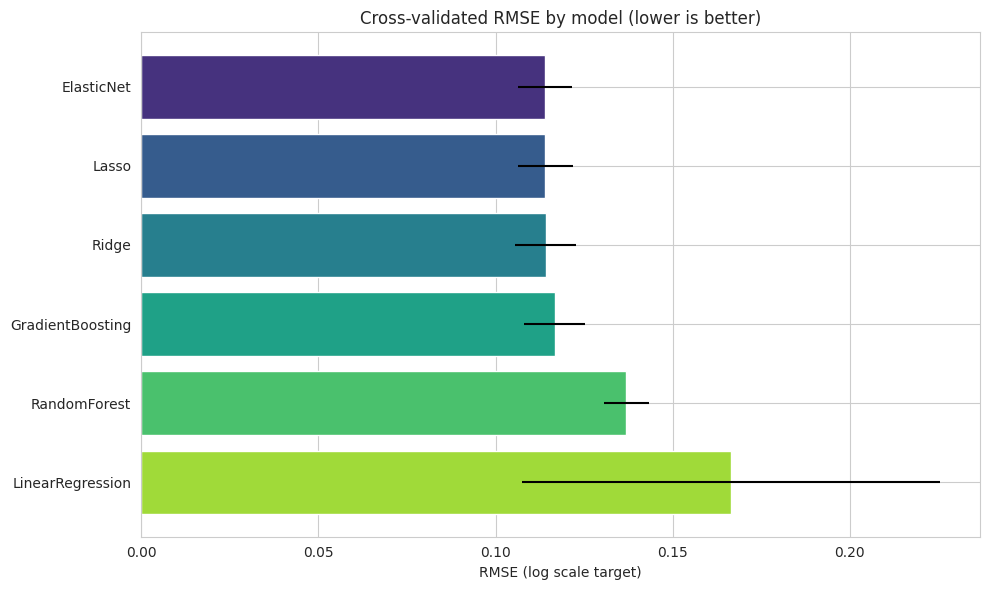

In [34]:
plt.figure(figsize=(10, 6))
plt.barh(results_df.index, results_df['RMSE_mean'], xerr=results_df['RMSE_std'], color=sns.color_palette('viridis', len(results_df)))
plt.gca().invert_yaxis()
plt.title('Cross-validated RMSE by model (lower is better)')
plt.xlabel('RMSE (log scale target)')
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning

Instead of `RandomizedSearchCV`, we write the search as an explicit nested loop over a small grid for Gradient Boosting (our best individual tree model from Section 5): for every combination of `n_estimators`, `max_depth`, and `learning_rate`, run the same manual `rmse_cv` from Section 5 and keep the combination with the lowest mean RMSE. It's more code than calling a library function, but every trial and its score is visible as it runs.

In [35]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.08],
}

best_score = np.inf
best_params = None
trial_log = []

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            candidate = GradientBoostingRegressor(
                n_estimators=n_est, max_depth=depth, learning_rate=lr,
                max_features='sqrt', min_samples_leaf=15, min_samples_split=10,
                loss='huber', random_state=RANDOM_STATE,
            )
            score = rmse_cv(candidate).mean()
            trial_log.append({'n_estimators': n_est, 'max_depth': depth,
                               'learning_rate': lr, 'rmse': score})
            if score < best_score:
                best_score = score
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr}

trial_log_df = pd.DataFrame(trial_log).sort_values('rmse').reset_index(drop=True)
print('Best params:', best_params)
print('Best CV RMSE: %.4f' % best_score)
trial_log_df.head(10)


Best params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05}
Best CV RMSE: 0.1156


,n_estimators,max_depth,learning_rate,rmse
0,400,4,0.05,0.115579
1,400,5,0.05,0.115876
2,400,5,0.08,0.116008
3,400,5,0.03,0.116151
4,300,5,0.08,0.116265
5,400,4,0.08,0.116500
6,300,4,0.05,0.116657
7,300,5,0.05,0.116660
8,400,4,0.03,0.116743
9,300,4,0.08,0.116797


In [36]:
best_gbr = GradientBoostingRegressor(
    **best_params,
    max_features='sqrt', min_samples_leaf=15, min_samples_split=10,
    loss='huber', random_state=RANDOM_STATE,
)
score = rmse_cv(best_gbr)
results['GradientBoosting (tuned)'] = score
print(f'Tuned Gradient Boosting RMSE: {score.mean():.4f} (+/- {score.std():.4f})')


Tuned Gradient Boosting RMSE: 0.1156 (+/- 0.0082)


The same nested-loop pattern works for any estimator — widen `param_grid` or add an outer loop over `RandomForestRegressor` if you want to tune it too. It scales worse than `RandomizedSearchCV` as the grid grows (every combination is tried, not a random sample), so keep grids small and targeted at the parameters you expect to matter most.

## 7. Ensembling & Stacking

Averaging predictions from diverse models (different biases/variance profiles) usually beats any single model, because their errors partially cancel out.

### 7.1 Simple weighted average blend

In [37]:
# Fit each base model on the full training set
ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)
enet_pipe.fit(X_train, y_train)
rf.fit(X_train, y_train)
best_gbr.fit(X_train, y_train)

def blended_predict(X):
    return (0.20 * ridge_pipe.predict(X) +
            0.20 * lasso_pipe.predict(X) +
            0.20 * enet_pipe.predict(X) +
            0.15 * rf.predict(X) +
            0.25 * best_gbr.predict(X))

# Sanity-check the blend's in-sample RMSE (not a substitute for CV, just a smell test)
train_pred = blended_predict(X_train)
print('Blend RMSE on training data: %.4f' % np.sqrt(np.mean((train_pred - y_train) ** 2)))


Blend RMSE on training data: 0.0835


Weights above are a reasonable starting point (linear models + trees, roughly balanced, with a bit more weight on the tuned Gradient Boosting model) — tune them by checking blend RMSE on held-out folds, or search them with `scipy.optimize.minimize` against out-of-fold predictions.

### 7.2 Manual out-of-fold stacking

Rather than `StackingRegressor`, we build the stack by hand so the mechanics are explicit:

1. For each base model, loop over the same 5 folds used earlier. On each fold, fit a fresh clone on the training portion and predict on the held-out portion — those held-out predictions are **out-of-fold (OOF)** predictions, meaning the model never saw that row during training. Collecting them across all folds gives one honest prediction per training row.
2. Average that model's 5 fold-fitted predictions on the real test set, since we don't have OOF test labels.
3. Stack the OOF predictions from all base models into a small "meta-feature" matrix (one column per base model) and fit a simple `RidgeCV` on top of it — the meta-model learns how much to trust each base model.

This is exactly what `StackingRegressor` does internally, just written out.

In [38]:
base_models = {
    'ridge': ridge_pipe,
    'lasso': lasso_pipe,
    'enet': enet_pipe,
    'rf': RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=5,
                                 random_state=RANDOM_STATE, n_jobs=-1),
    'gbr': GradientBoostingRegressor(**best_params, max_features='sqrt',
                                      min_samples_leaf=15, min_samples_split=10,
                                      loss='huber', random_state=RANDOM_STATE),
}

oof_preds = pd.DataFrame(np.zeros((len(X_train), len(base_models))), columns=base_models.keys())
test_preds = pd.DataFrame(np.zeros((len(X_test), len(base_models))), columns=base_models.keys())

for name, base_model in base_models.items():
    fold_test_preds = np.zeros((len(X_test), n_folds))
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        m = clone(base_model)
        m.fit(X_train.iloc[train_idx], y_train[train_idx])
        oof_preds.loc[val_idx, name] = m.predict(X_train.iloc[val_idx])
        fold_test_preds[:, fold_i] = m.predict(X_test)
    test_preds[name] = fold_test_preds.mean(axis=1)   # average across the 5 fold-fitted models
    oof_rmse = np.sqrt(np.mean((oof_preds[name].values - y_train) ** 2))
    print(f'{name:>6s}  OOF RMSE: {oof_rmse:.4f}')


 ridge  OOF RMSE: 0.1145


 lasso  OOF RMSE: 0.1144


  enet  OOF RMSE: 0.1141


    rf  OOF RMSE: 0.1371


   gbr  OOF RMSE: 0.1159


In [39]:
meta_model = RidgeCV(alphas=np.logspace(-3, 3, 50))
meta_model.fit(oof_preds, y_train)

stack_oof_pred = meta_model.predict(oof_preds)
stack_rmse = np.sqrt(np.mean((stack_oof_pred - y_train) ** 2))
print(f'Stacked model OOF RMSE: {stack_rmse:.4f}')
print('Meta-model weights:', dict(zip(base_models.keys(), np.round(meta_model.coef_, 3))))


Stacked model OOF RMSE: 0.1100
Meta-model weights: {'ridge': np.float64(0.132), 'lasso': np.float64(0.192), 'enet': np.float64(0.232), 'rf': np.float64(0.017), 'gbr': np.float64(0.448)}


Compare `stack_rmse` against the individual OOF scores above and the blend's smell-test; whichever is lowest is what you should submit. The meta-model's learned weights are also worth a look — they tell you which base models it's actually leaning on.

## 8. Final Model, Prediction & Submission

Use the stacking meta-model on the test-set predictions gathered in Section 7 (`test_preds`, each column already the fold-averaged prediction from a base model), undo the `log1p` transform with `expm1`, and write the Kaggle submission file.

In [40]:
test_pred_log = meta_model.predict(test_preds)
test_pred = np.expm1(test_pred_log)   # inverse of log1p

submission = pd.DataFrame({'Id': test_ID, 'SalePrice': test_pred})
submission.to_csv('submission.csv', index=False)
submission.head()


,Id,SalePrice
0,1461,117325.448840
1,1462,153768.457586
2,1463,184148.045409
3,1464,194899.575702
4,1465,193509.326655


`submission.csv` is now formatted exactly as `sample_submission.csv` requires and is ready to upload on the [competition submission page](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/submit).

## 9. Conclusion & Next Steps

**What we did:**
- Explored the target and features, and found `SalePrice` needed a log transform and the dataset had a few extreme outliers
- Cleaned ~30 columns of missing values, distinguishing "genuinely missing" from "feature doesn't exist"
- Engineered composite features (total square footage, house age, total bathrooms), ordinal-encoded quality features, and fixed skewed numeric columns
- Benchmarked linear (Ridge/Lasso/ElasticNet) and tree-based (Random Forest, Gradient Boosting) scikit-learn models under a hand-written 5-fold cross-validation loop — no external boosting libraries, no black-box CV helpers
- Tuned Gradient Boosting with an explicit nested grid loop, then combined all models into a manually-built out-of-fold stacking ensemble for the final submission

**Ways to push the leaderboard score further:**
- Feature selection: drop near-zero-variance dummy columns created by one-hot encoding
- More feature interactions (e.g., `OverallQual * GrLivArea`)
- Target-encode `Neighborhood` instead of one-hot (with proper out-of-fold encoding to avoid leakage)
- If you're open to external libraries again, XGBoost/LightGBM/CatBoost typically edge out plain Gradient Boosting on this dataset, and `optuna` can replace the manual grid search with a smarter (Bayesian) one
- Blend weight optimization against true out-of-fold predictions rather than hand-picked weights
